# A simple Localization Problem

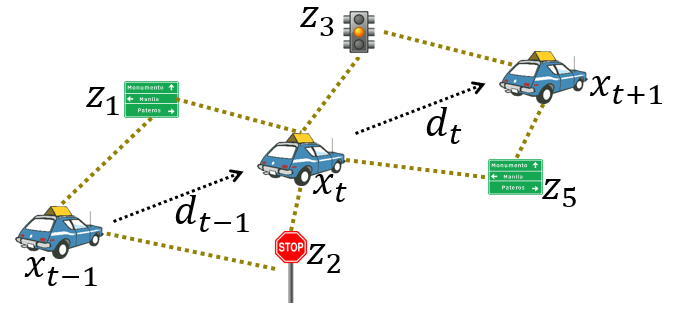

### Given
1. Map: Global position of landmarks as $z_i$
1. Motion model of the robot, e.g. $x_{t+1} = x_t + d_t + \epsilon_t$, $\epsilon_t \sim \mathcal{N}(0, R_t)$.
1. Observations model as the bearing of the landmarks $f_{i,t} = H(z_i  - x_t) + \eta_{i,t}$, $\eta_{i,t} \sim \mathcal{N}(0, Q_t)$.
1. Local observations at each time step for some of the landmarks $f_{i,t}$.
1. Initial Location $x_0 \sim \mathcal{N}(\mu_0, \Sigma_0)$.

### Find

The position and orientation of the robot, $x_t$


## Data generation

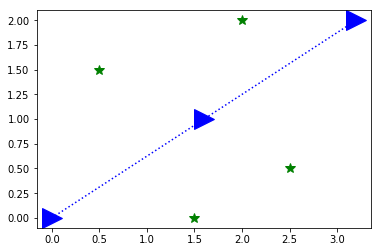

In [ ]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

# Comment these lines for randomization
# SEED = 1020273
# np.random.seed(SEED)

# True x. Not known to the algorithm but known to the simulator or the environment
x = np.array([[0, 0],
             [1.6, 1.0],
             [3.2, 2.0]])
# Given
# z for i-1 = [0, 1, 2, 3]
z = np.array([[0.5, 1.5],
              [1.5, 0],
              [2.0, 2.0],
              [2.5, 0.5]])

# Let's plot our global markers
plt.plot(z[:, 0], z[:, 1], color='g', marker='*', markersize=10, linestyle='')
plt.plot(x[:, 0], x[:, 1], color='b', marker='>', markersize=20, linestyle=':')

In [ ]:
# Given motion model noise covariance
R = np.eye(2) * 0.05

# Generate noise
T, D = x.shape
epsilon = np.random.multivariate_normal(np.zeros(D), R, size=T-1)

# compute noisy odometry
# d for t = [0, 1]
d = np.diff(x, axis=0) + epsilon
d

array([[1.47509542, 1.43827493],
       [1.15862981, 0.74611534]])

In [ ]:
# Given observation model noise covariance
Q = np.eye(1) * 0.07
T, D = x.shape
# Given oservation Model
H = np.array([[3, 2]])

# time time t = 0 only z_1, and z_0 are visible
# at time t = 1, all z are visible
# at time t = 2, only z_2 and z_3 are visible
visible_all_t = [[0,1], range(4), [2,3]]
f_i_t = []
for t, visible_t in enumerate(visible_all_t):
  diff_i_t = z[visible_t, np.newaxis, :] - x[np.newaxis, t, :]
  diff_i_t = diff_i_t.reshape(-1, D)
  eta = np.random.multivariate_normal(np.zeros(1), Q, size=len(visible_t))
  f_i_t.append(diff_i_t @ H.T + eta)

f_i_t

[array([[4.74946164],
        [5.10238605]]), array([[-2.38472248],
        [-2.69799125],
        [ 3.13283869],
        [ 1.57986606]]), array([[-3.52348093],
        [-5.20147678]])]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/drive


In [ ]:
np.savez_compressed('/content/drive/My Drive/Colab Notebooks/simple_localization_problem_data.npz',
                 obs_vals_0=f_i_t[0],
                 obs_vals_1=f_i_t[1],
                 obs_vals_2=f_i_t[2],
                 obs_ids_0=visible_all_t[0],
                 obs_ids_1=visible_all_t[1],
                 obs_ids_2=visible_all_t[2],
                 d=d,
                 z=z,
                 Q=Q,
                 R=R,
                 H=H,
                 mu0=x[0],
                  sigma0=np.eye(x[0].shape[0]))